## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# ── Global plot style ────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11})

## 2. Load Data

In [ ]:
path = r"" # <-- your dataset path
df = pd.read_csv(path)
print(f"shape: {df.shape}")
df.head()

shape: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## 3. EDA

### 3.1. data quality

In [104]:
print("======= dtypes =======")
print(df.dtypes)
print()

print("======= missing values =======")
print(df.isna().sum())
print()

print("======= duplicates =======")
print(f"duplicated rows : {df.duplicated().sum()}")

df = df.drop_duplicates()

print(f"shape after dropping duplicates: {df.shape}")


======= dtypes =======
name                 str
year               int64
selling_price      int64
km_driven          int64
fuel                 str
seller_type          str
transmission         str
owner                str
mileage              str
engine               str
max_power            str
torque               str
seats            float64
dtype: object

======= missing values =======
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

======= duplicates =======
duplicated rows : 1202
shape after dropping duplicates: (6926, 13)


### 3.2 handling missing values

In [105]:
df = df.dropna()
print(f"Shape after dropping NaN values: {df.shape}")

Shape after dropping NaN values: (6717, 13)


### 3.3 handling dtypes

In [106]:
cols_to_handle = ['mileage', 'engine', 'max_power']

for col in cols_to_handle:
    df[col] = df[col].str.extract(r"(\d+\.?\d*)").astype(float)

df[cols_to_handle].dtypes

mileage      float64
engine       float64
max_power    float64
dtype: object

In [107]:
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats
count,6717.000000,6.717000e+03,6.717000e+03,6717.000000,6717.000000,6717.000000,6717.000000
mean,2013.611136,5.263860e+05,7.339834e+04,19.466585,1430.985857,87.766100,5.434271
std,3.897402,5.235504e+05,5.870328e+04,4.048102,493.469198,31.724555,0.983805
min,1994.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,32.800000,2.000000
25%,2011.000000,2.500000e+05,3.800000e+04,16.800000,1197.000000,67.100000,5.000000
50%,2014.000000,4.200000e+05,6.820300e+04,19.440000,1248.000000,81.830000,5.000000
75%,2017.000000,6.500000e+05,1.000000e+05,22.500000,1498.000000,100.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000


### 3.4 handling data errors

In [108]:
# We observe that the mileage has min values of 0 which is an error, and we need to handle that
print(f"Number of mileage null values: {df[df['mileage']==0].shape[0]}")

# Dropping rows with null mileage
df.loc[df['mileage'] == 0, 'mileage'] = np.nan
df = df.dropna()

print(f"Data new shape: {df.shape}")

Number of mileage null values: 15
Data new shape: (6702, 13)


In [109]:
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats
count,6702.000000,6.702000e+03,6.702000e+03,6702.000000,6702.000000,6702.000000,6702.000000
mean,2013.613847,5.260229e+05,7.342715e+04,19.510154,1430.707550,87.765621,5.436138
std,3.897405,5.224831e+05,5.874013e+04,3.946346,493.016491,31.703000,0.982929
min,1994.000000,2.999900e+04,1.000000e+00,9.000000,624.000000,32.800000,4.000000
25%,2011.000000,2.500000e+05,3.800000e+04,16.800000,1197.000000,68.000000,5.000000
50%,2014.000000,4.200000e+05,6.837950e+04,19.490000,1248.000000,81.830000,5.000000
75%,2017.000000,6.500000e+05,1.000000e+05,22.540000,1498.000000,100.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000


### 3.5 target distribution

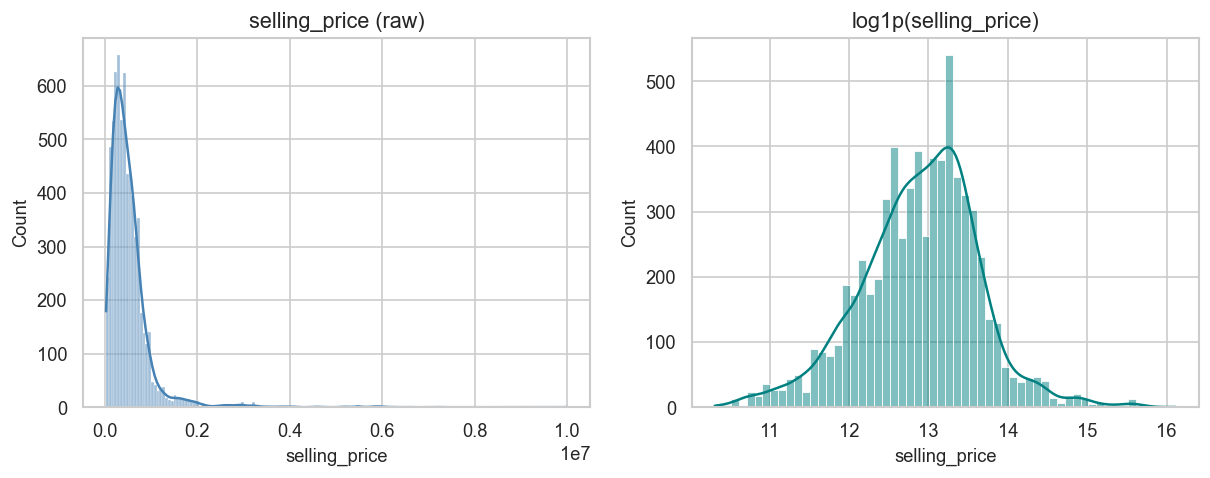

raw selling_price:  5.59
log selling_price: -0.15


In [110]:
fig, axes = plt.subplots(1, 2, figsize= (12,4))

# Raw target
sns.histplot(df['selling_price'], ax= axes[0], kde= True, color= 'steelblue')
axes[0].set_title('selling_price (raw)')

# Log target
sns.histplot(np.log1p(df['selling_price']), ax= axes[1], kde= True, color= 'teal')
axes[1].set_title('log1p(selling_price)')

plt.show()

# Skewness
print(f"raw selling_price: {df['selling_price'].skew(): .2f}")
print(f"log selling_price: {np.log1p(df['selling_price']).skew(): .2f}")

### 3.6. Numerical feature distributions

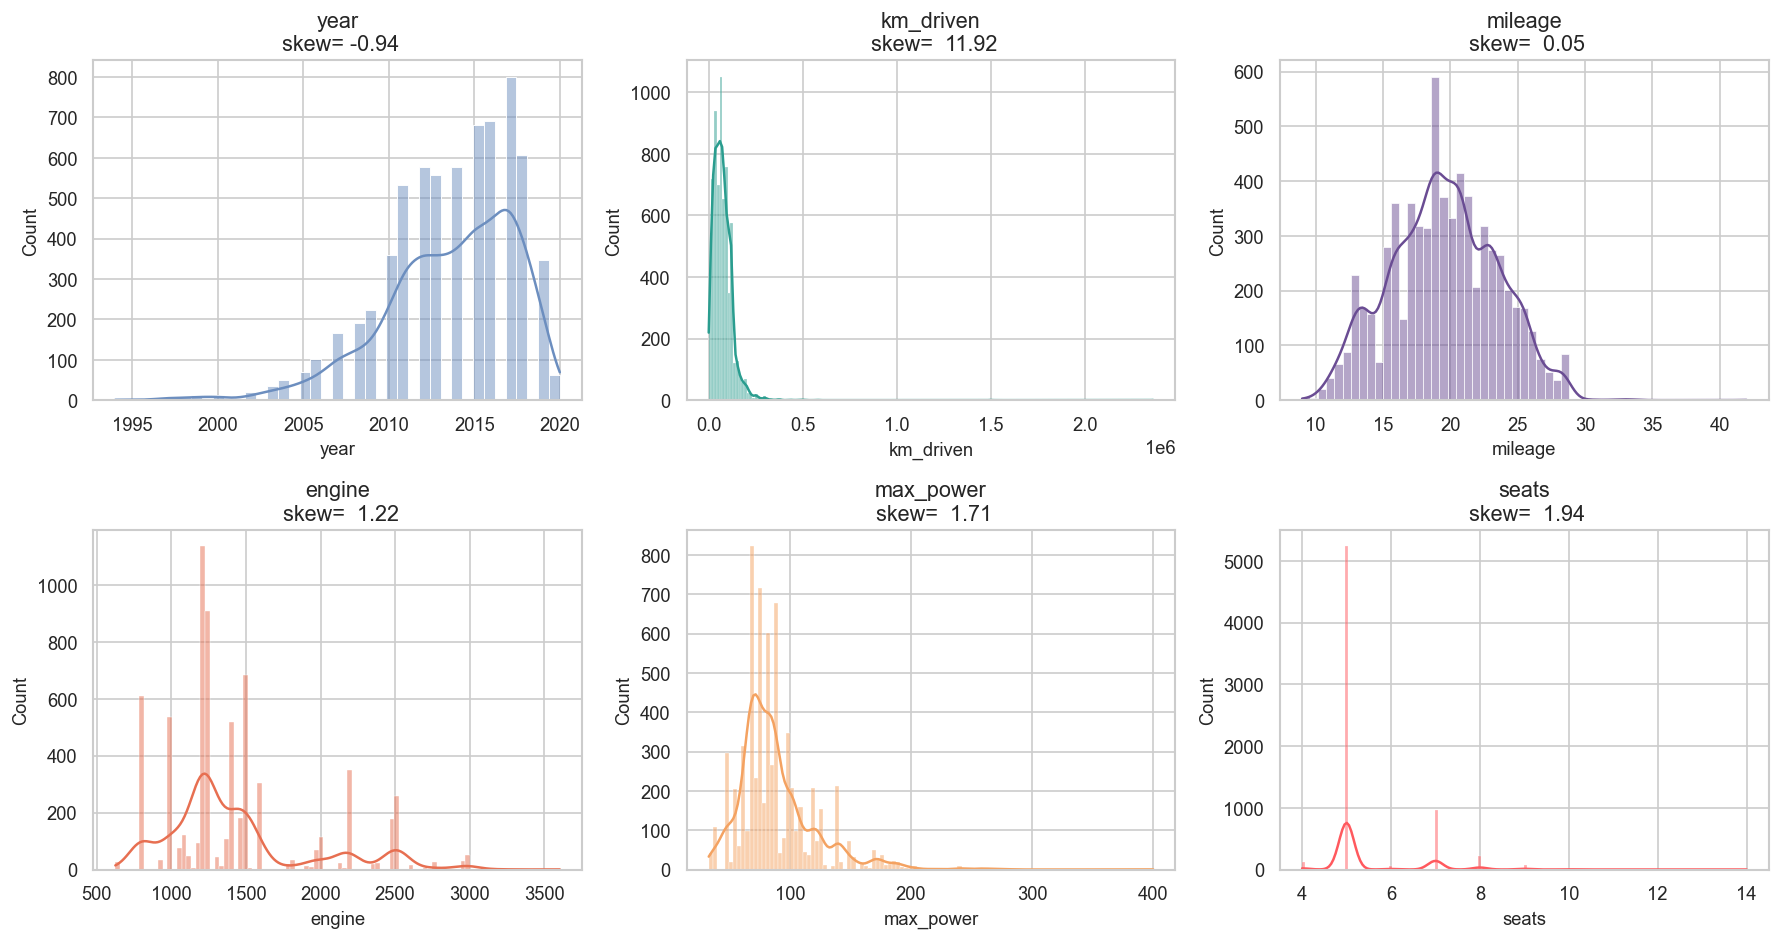

In [112]:
num_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
palette  = ["#6C8EBF", "#2A9D8F", '#6A4C93', "#E76F51", "#F4A261", "#FF595E"] 

fig, axes = plt.subplots(2,3, figsize=(15,8))

for col, axe, color in zip(num_cols, axes.flatten(), palette):
    sns.histplot(data= df, x= col, ax= axe, kde= True, color= color)
    axe.set_title(f"{col}\n skew= {df[col].skew(): .2f}")
plt.tight_layout()
plt.show()

### 3.7 categorical feature distributions

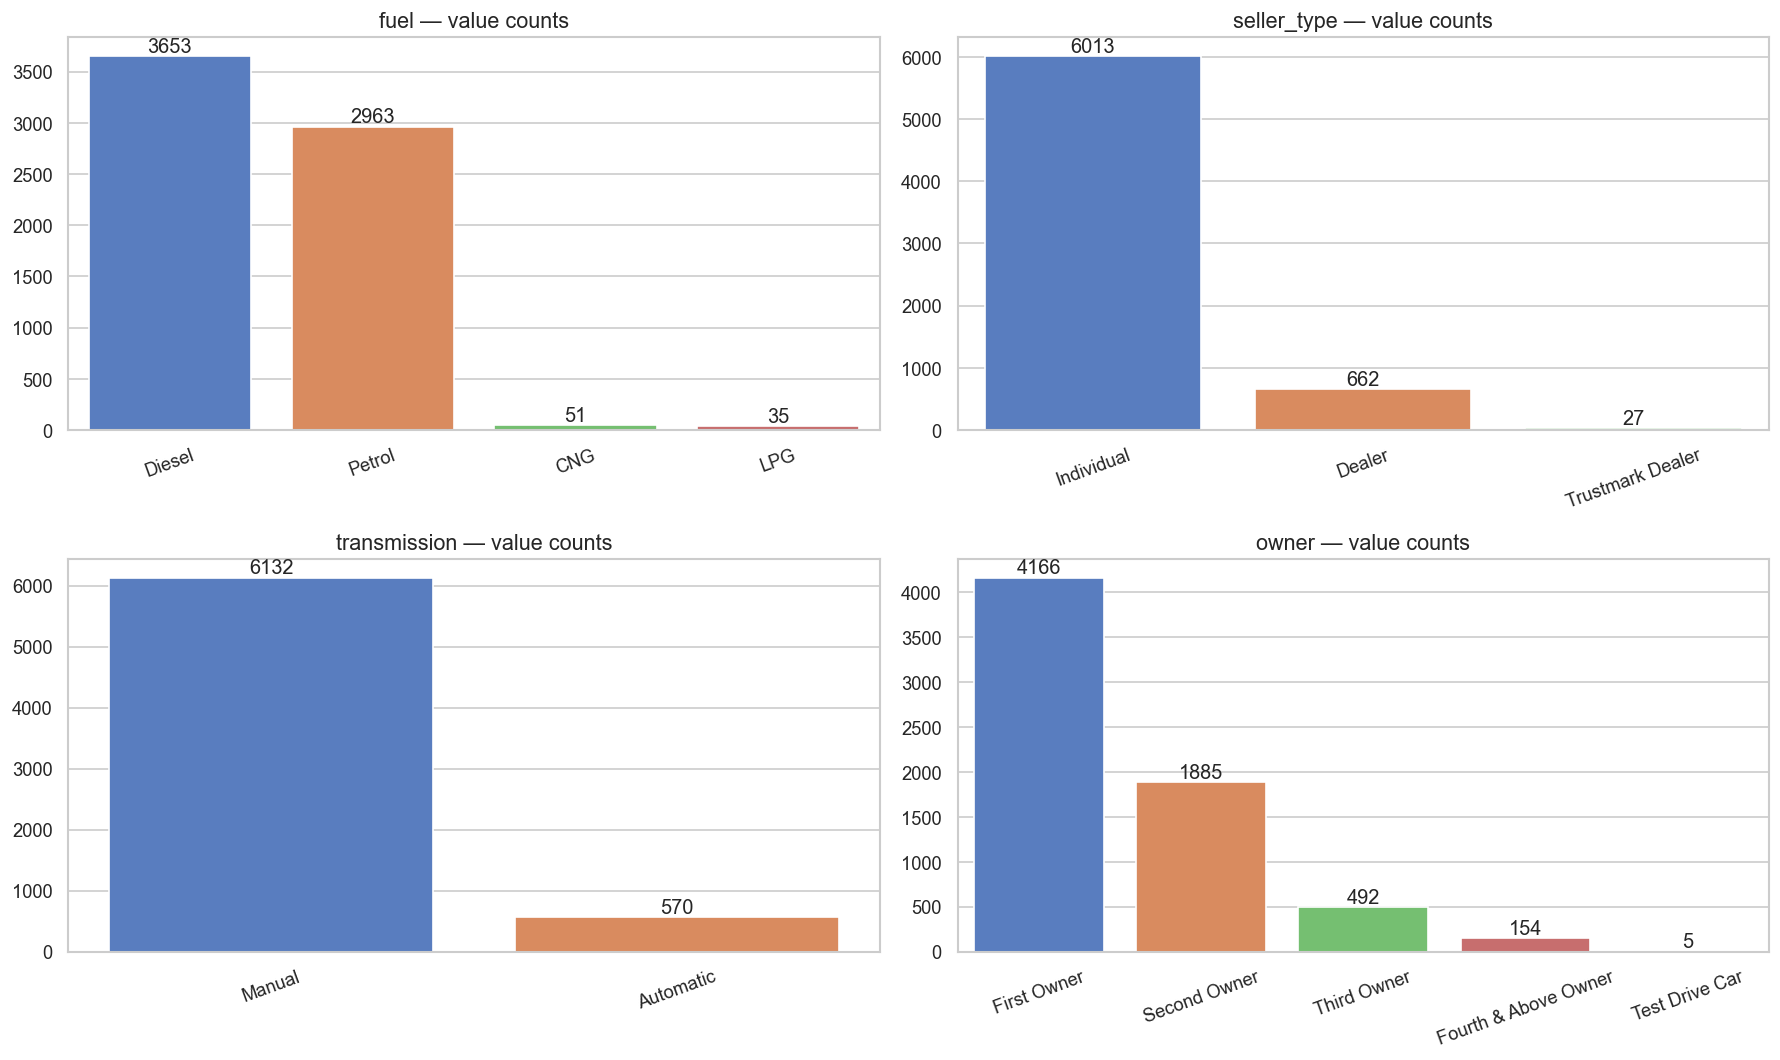

In [113]:
categ_cols = ['fuel', 'seller_type', 'transmission', 'owner']

fig, axes = plt.subplots(2, 2, figsize= (15, 9))
for col, axe in zip(categ_cols, axes.flatten()):
    counts = df[col].value_counts()
    sns.barplot(x= counts.index, y= counts.values, ax= axe, palette= 'muted')
    axe.set_title(f"{col} — value counts")
    axe.set_xlabel('')
    axe.tick_params(axis= 'x', rotation= 20)
    # annotate bars with counts
    for container in axe.containers:
        axe.bar_label(container)

plt.tight_layout()
plt.show()

### 3.8. bivariate analysis — categorical .vs target

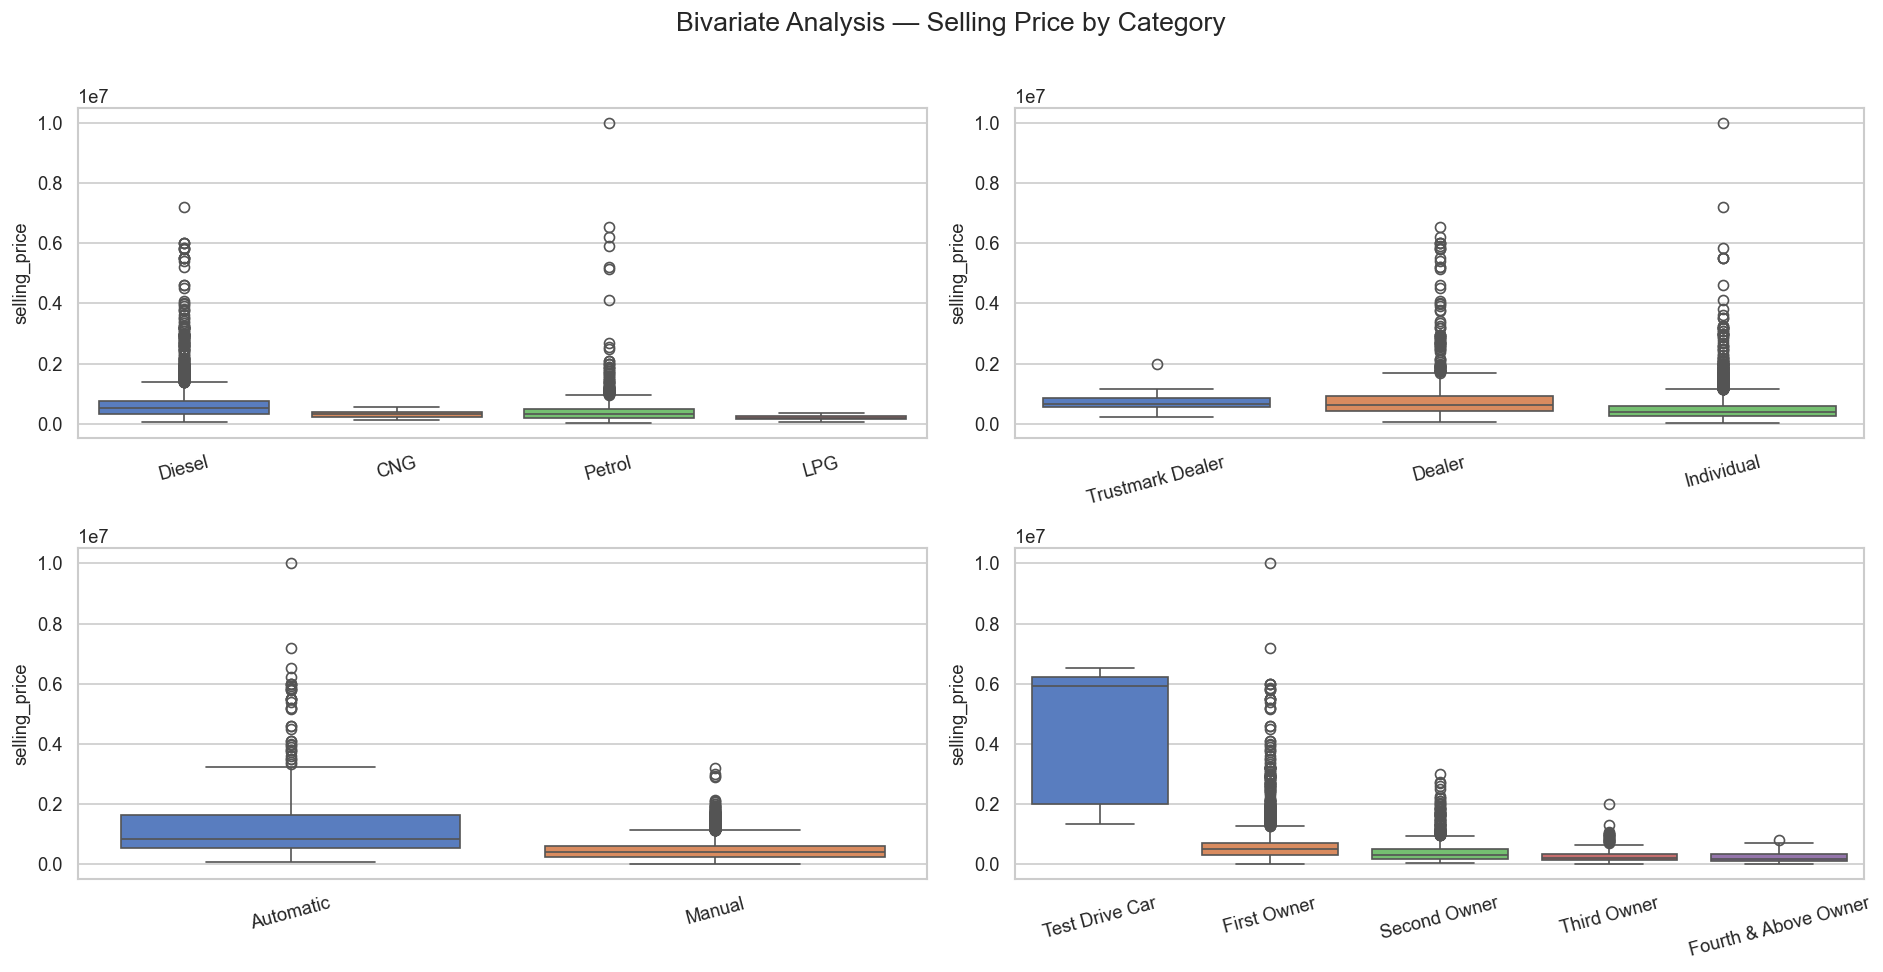

In [114]:
fig, axes = plt.subplots(2, 2, figsize= (16,8))

for col, axe in zip(categ_cols, axes.flatten()):
    # set order by median
    order = df.groupby(col)['selling_price'].median().sort_values(ascending= False).index
    sns.boxplot(data= df, x= col, y= 'selling_price', ax= axe, order= order, palette= 'muted')

    axe.tick_params(axis='x', rotation=15)
    axe.set_xlabel('')
plt.suptitle('Bivariate Analysis — Selling Price by Category', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.9. bivariate analysis — numerical .vs target

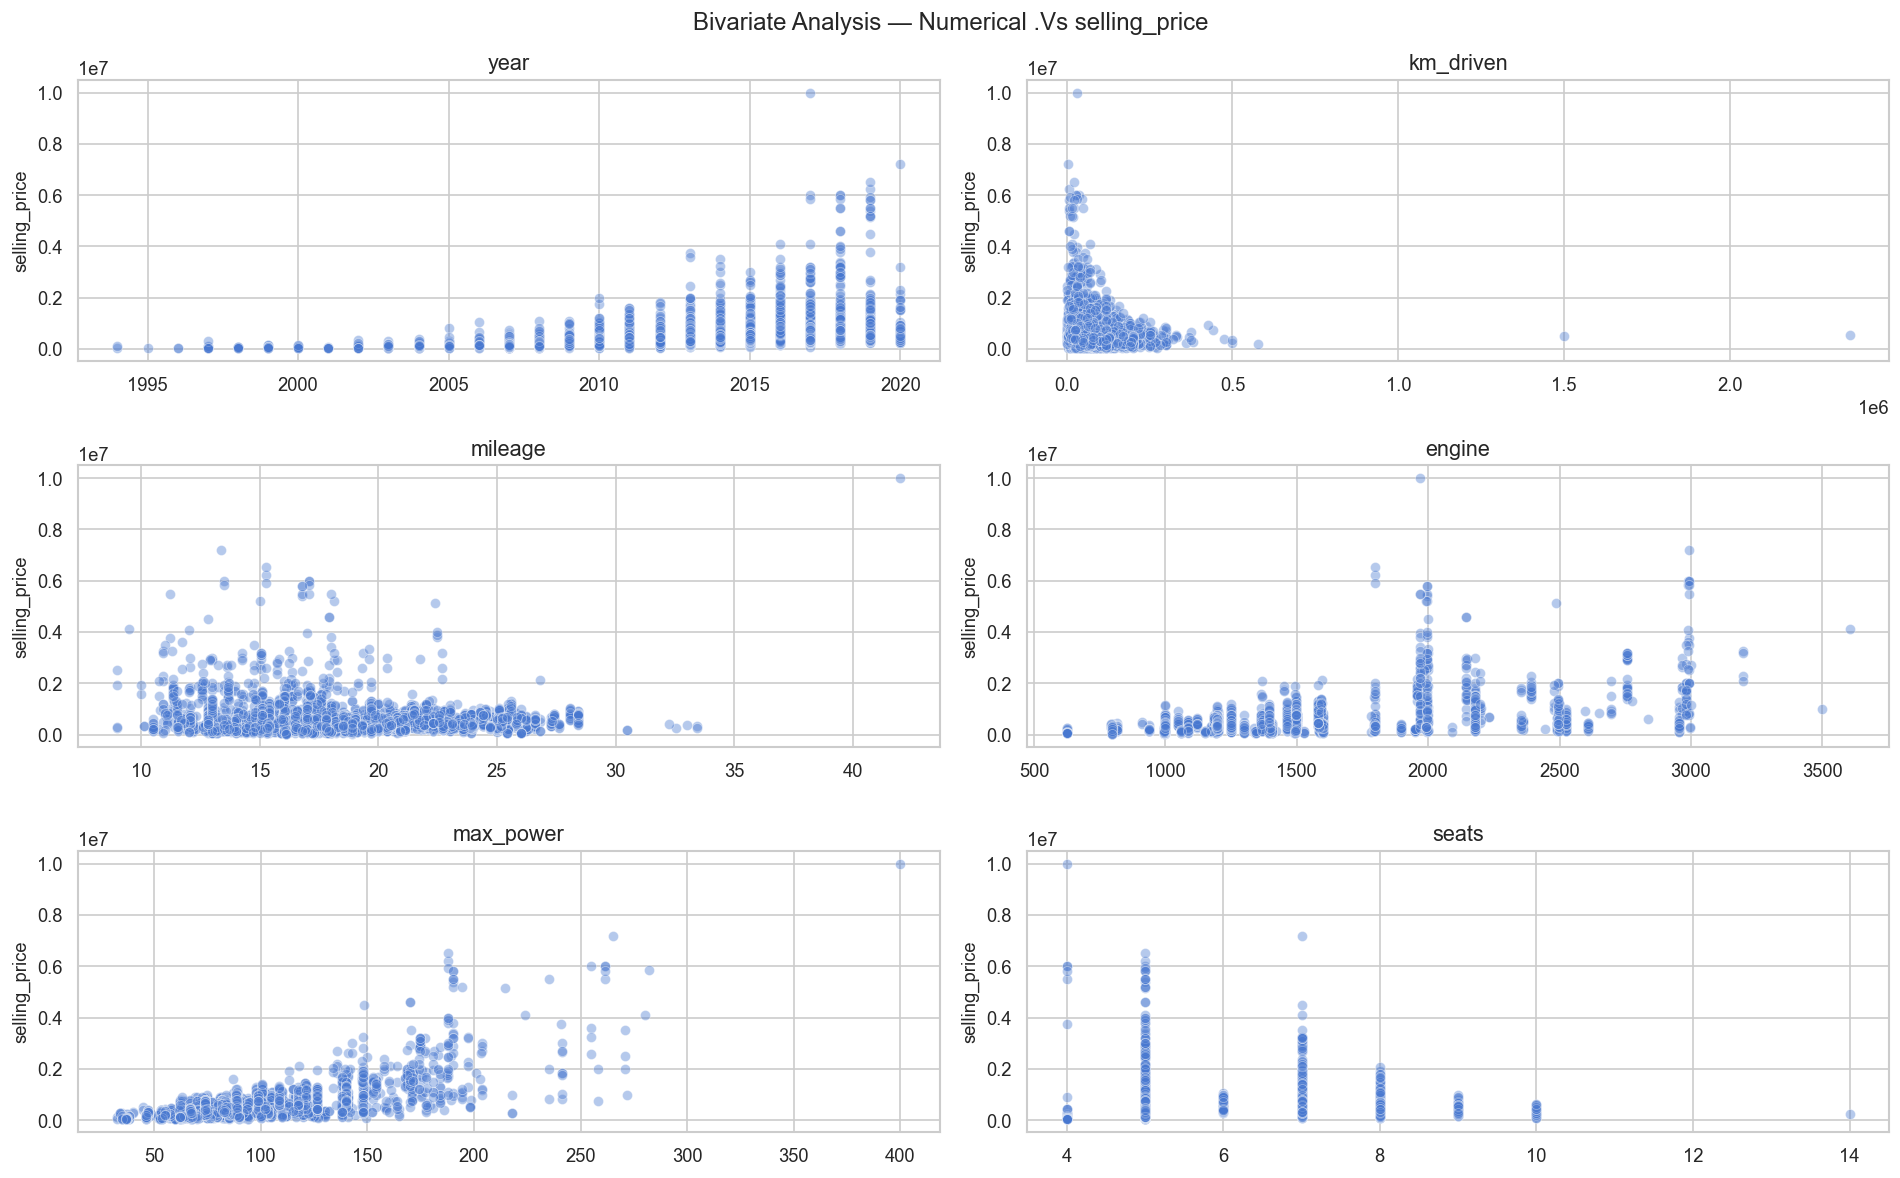

In [115]:

fig, axes = plt.subplots(3,2, figsize= (16,10))

for col, axe in zip(num_cols, axes.flatten()):
    sns.scatterplot(x= df[col], y= df['selling_price'], ax= axe, alpha= 0.4)
    axe.set_title(col)
    axe.set_xlabel('')
plt.suptitle('Bivariate Analysis — Numerical .Vs selling_price')
plt.tight_layout()
plt.show()


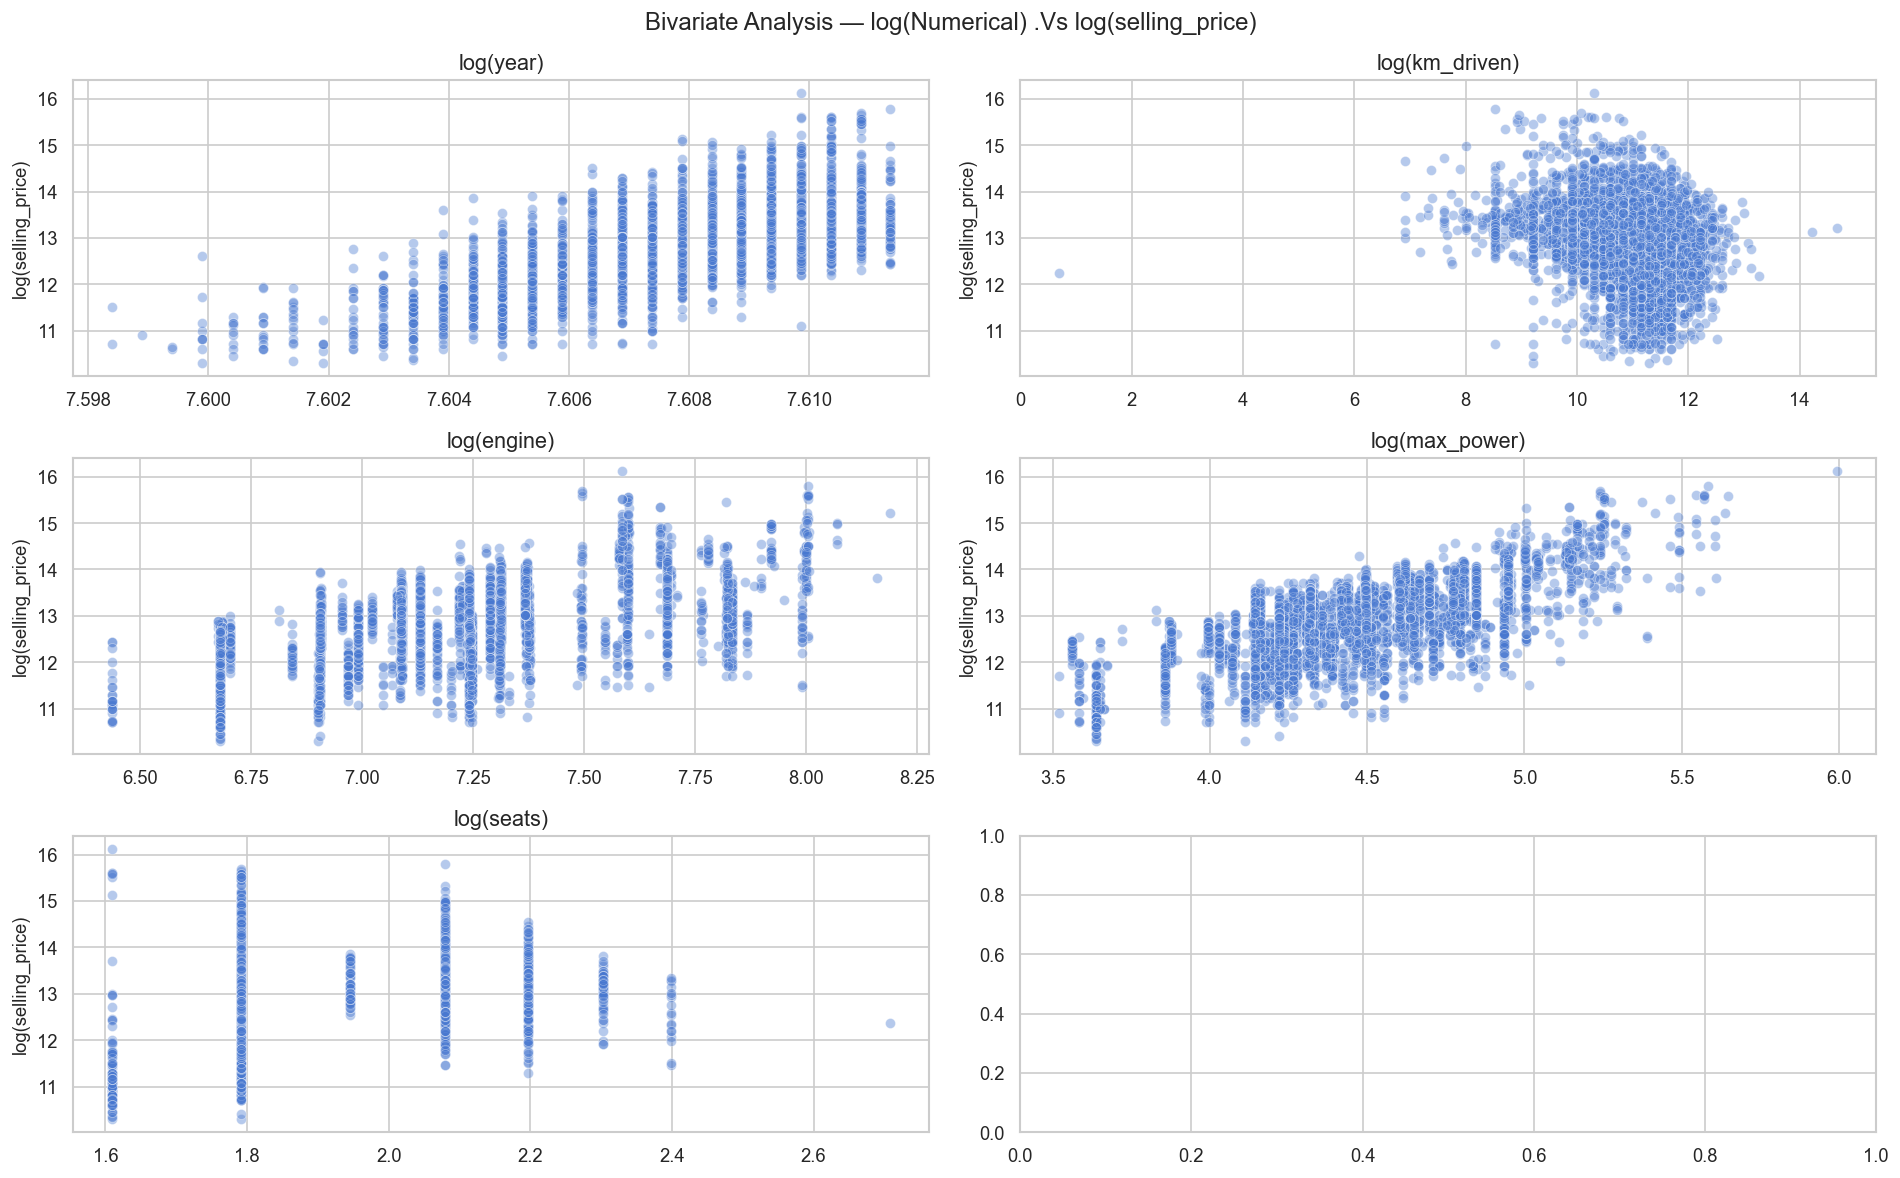

In [116]:
skewed_features = ['year', 'km_driven', 'engine', 'max_power', 'seats', 'selling_price']
fig, axes = plt.subplots(3,2, figsize= (16,10))

for col, axe in zip(skewed_features[:-1], axes.flatten()):
    sns.scatterplot(x= np.log1p(df[col]), y= np.log1p(df['selling_price']), ax= axe, alpha= 0.4)
    axe.set_title(f'log({col})')
    axe.set_xlabel('')
    axe.set_ylabel('log(selling_price)')
plt.suptitle('Bivariate Analysis — log(Numerical) .Vs log(selling_price)')
plt.tight_layout()
plt.show()


### 3.10. numerical correlations

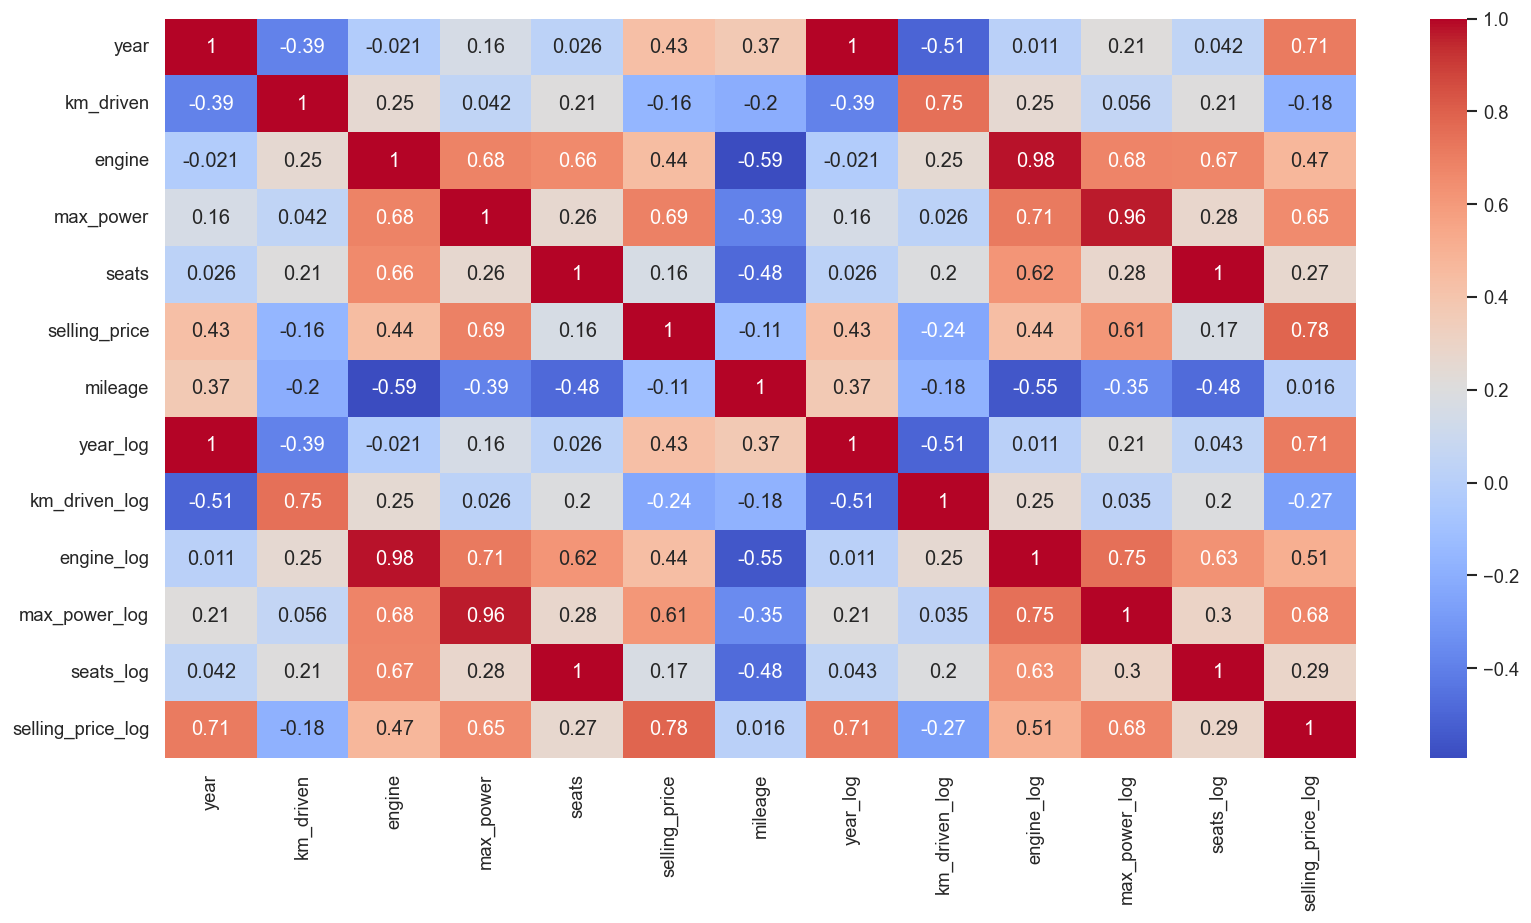

In [117]:
# Use log-transformed versions for correlation since features are skewed
corr_df = df[skewed_features+['mileage']].copy()
for col in skewed_features:
    corr_df[f'{col}_log'] = np.log1p(corr_df[col])

# heatmap
plt.figure(figsize= (16,8))
sns.heatmap(corr_df.corr(), annot= True, cmap= 'coolwarm')
plt.show()



## 4. Preprocessing

In [118]:
df_model = df.drop(['name', 'torque'], axis= 1).copy()

# 1. __________________ log transform __________________
for feature in skewed_features[1:]:
    df_model[f'{feature}_log'] = np.log1p(df_model[feature])

# 2. __________________ feature engineering __________________
# >>>> Car age is more interpretable and more linearly related to price than year
df_model['car_age'] = 2026 - df_model['year']

# 3. __________________ categorical feature encoding __________________
# >>>> ordinal encoding
owner_order = {
    'Test Drive Car':      0,
    'First Owner':         1,
    'Second Owner':        2,
    'Third Owner':         3,
    'Fourth & Above Owner':4
}
df_model['owner_encoded'] = df_model['owner'].map(owner_order)
# >>>> one-hot encoding
df_model = pd.get_dummies(df_model, columns= ['fuel', 'seller_type', 'transmission'], drop_first= True, dtype= int)

# 4. __________________ feature matrix and target __________________
drop_cols = ['year', 'selling_price', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats', 'selling_price_log']
target = 'selling_price_log'

X = df_model.drop(drop_cols, axis= 1)
y = df_model[target]

print('Features used:')
print(X.columns.tolist())
print(f'\nX shape: {X.shape}')

Features used:
['km_driven_log', 'engine_log', 'max_power_log', 'seats_log', 'car_age', 'owner_encoded', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual']

X shape: (6702, 12)


## 5. Train / Test Split

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (5361, 12) | Test: (1341, 12)


## 6. Pipeline

In [120]:
def make_pipeline(model):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model',  model)
    ])

pipelines = {
    'Linear Regression': make_pipeline(LinearRegression()),
    'Ridge (k=1)':       make_pipeline(Ridge(alpha=1.0)),
    'Ridge (k=10)':      make_pipeline(Ridge(alpha=10.0)),
    'Ridge (k=100)':     make_pipeline(Ridge(alpha=100.0)),
    'Lasso (k=0.001)':   make_pipeline(Lasso(alpha=0.001, max_iter=10000)),
    'Lasso (k=0.01)':    make_pipeline(Lasso(alpha=0.01,  max_iter=10000)),
    'Lasso (k=0.1)':     make_pipeline(Lasso(alpha=0.1,   max_iter=10000)),
}

## 7. Cross Validaton — Model and Hyperparameter selection

In [121]:
kf = KFold(n_splits= 5, shuffle= True, random_state= 42)
cv = {}

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv= kf, scoring= 'r2')
    cv[name] = scores
    print(f'{name:<25}: R² = {scores.mean():.6f} | std =  {scores.std():.6f}')

# choosing the optimal learning algorithm
best_model = max(cv, key= lambda k: cv[k].mean())
print(f"\nbest model: {best_model}")

Linear Regression        : R² = 0.835718 | std =  0.014464
Ridge (k=1)              : R² = 0.835720 | std =  0.014459
Ridge (k=10)             : R² = 0.835726 | std =  0.014411
Ridge (k=100)            : R² = 0.835508 | std =  0.013989
Lasso (k=0.001)          : R² = 0.835723 | std =  0.014354
Lasso (k=0.01)           : R² = 0.834819 | std =  0.013300
Lasso (k=0.1)            : R² = 0.779912 | std =  0.009216

best model: Ridge (k=10)


## 8. Training

In [128]:
best_pipe = pipelines[best_model]
best_pipe.fit(X_train, y_train)
y_pred_log = best_pipe.predict(X_test)

# metrics on log scale
print(f"MSE = {mean_squared_error(y_test, y_pred_log)}")
print(f"R2 = {r2_score(y_test, y_pred_log)}")
print(f"RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_log))}")
print(f"MAE = {mean_absolute_error(y_test, y_pred_log)}")

MSE = 0.08833102821840134
R2 = 0.838870442720938
RMSE = 0.29720536371068634
MAE = 0.22715135355703892


## 9. Diagnostic Plots

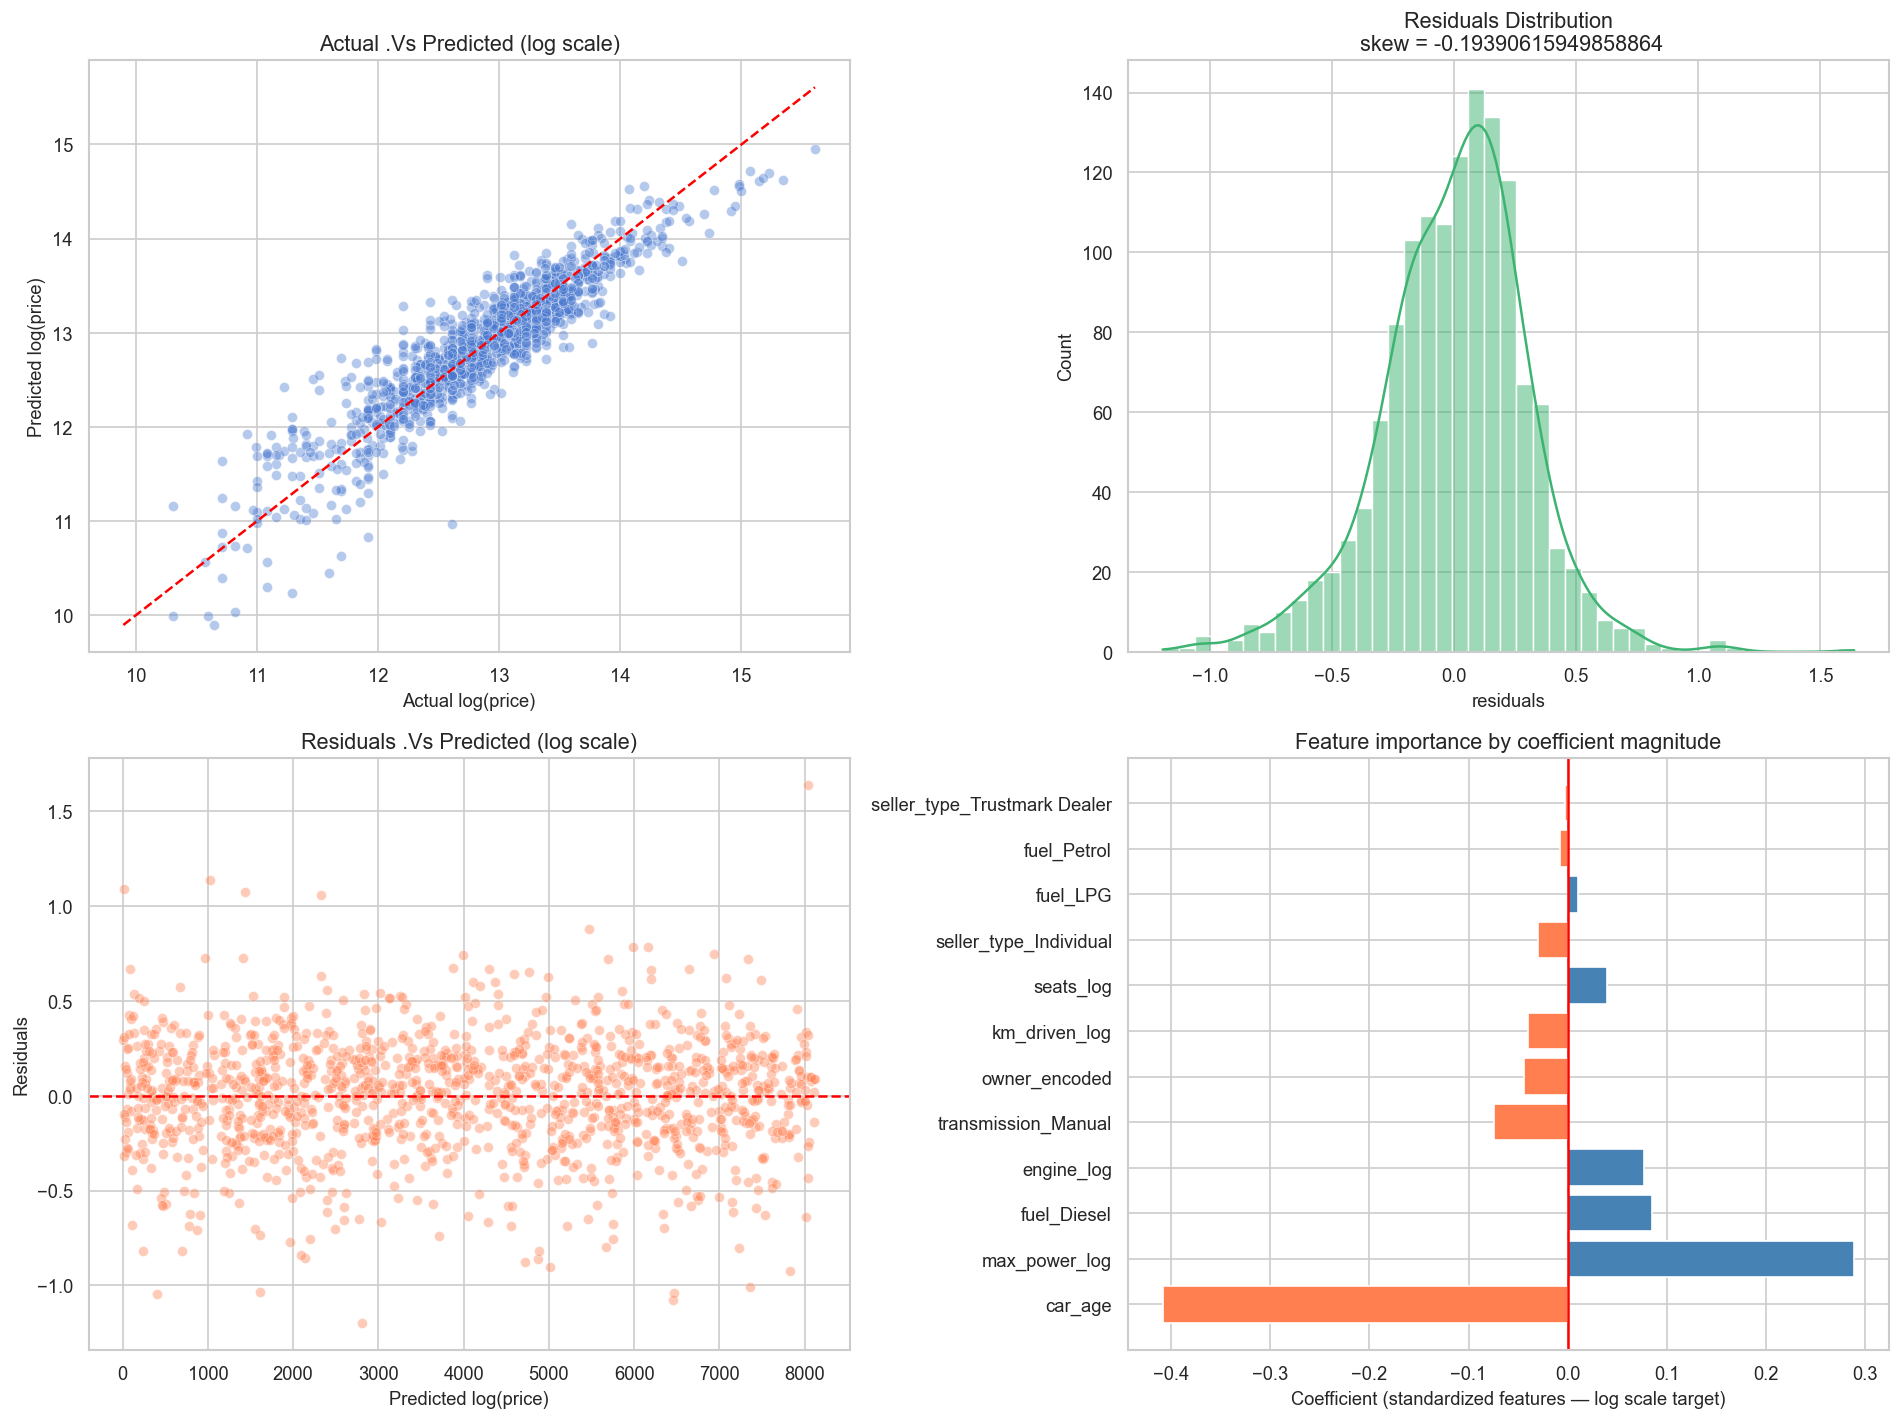

In [123]:
residuals = y_test - y_pred_log

fig, axes = plt.subplots(2, 2, figsize= (16,12))

# 1. ______________ Actual .Vs Predicted (log scale) ______________
limits = [
    min([min(y_test), min(y_pred_log)]),
    max([max(y_test), max(y_pred_log)])
]
sns.scatterplot(x= y_test, y= y_pred_log, ax= axes[0, 0], alpha= 0.4)
axes[0, 0].plot(limits, limits, linestyle= '--', color= 'red')
axes[0, 0].set_title("Actual .Vs Predicted (log scale)")
axes[0, 0].set_xlabel("Actual log(price)")
axes[0, 0].set_ylabel("Predicted log(price)")

# 2. ______________ Residuals Distribution ______________
sns.histplot(residuals, ax= axes[0, 1], kde= True, color= 'mediumseagreen')
axes[0, 1].set_title(f"Residuals Distribution\n skew = {residuals.skew()}")
axes[0, 1].set_xlabel("residuals")

# 3. ______________ Residuals .Vs Predicted (log scale) ______________
sns.scatterplot(residuals, ax= axes[1, 0], alpha= 0.4, color= 'coral')
axes[1, 0].axhline(y= 0, color= 'red', linestyle= '--')
axes[1, 0].set_title("Residuals .Vs Predicted (log scale)")
axes[1, 0].set_xlabel("Predicted log(price)")
axes[1, 0].set_ylabel("Residuals")

# 4. ______________ Coefficients Importance (log scale) ______________
# >>>> Extract coefficients from the pipeline's model step
model_step = best_pipe.named_steps['model']

coef_df = pd.DataFrame({
    'feature':     X.columns,
    'coefficient': model_step.coef_
}).sort_values('coefficient', key=abs, ascending=False)

bar_colors = ['steelblue' if coef > 0 else 'coral' for coef in coef_df['coefficient']]
axes[1, 1].barh(coef_df['feature'], coef_df['coefficient'], color= bar_colors)
axes[1, 1].axvline(x= 0, color= 'red')
axes[1, 1].set_title('Feature importance by coefficient magnitude')
axes[1, 1].set_xlabel('Coefficient (standardized features — log scale target)')

plt.tight_layout()
plt.show()

In [124]:
# Coefficients table
print('Coefficients table:')
print(coef_df.to_string(index= False))

Coefficients table:
                     feature  coefficient
                     car_age    -0.408933
               max_power_log     0.289429
                 fuel_Diesel     0.085058
                  engine_log     0.077601
         transmission_Manual    -0.073789
               owner_encoded    -0.044368
               km_driven_log    -0.039584
                   seats_log     0.039473
      seller_type_Individual    -0.029765
                    fuel_LPG     0.010200
                 fuel_Petrol    -0.007188
seller_type_Trustmark Dealer    -0.002669
